# FRLC Demo notebook

_Factor relaxation with latent coupling_ (abbreviated FRLC with the mnemonic "frolic") solves for a rank $r$ optimal transport coupling $\mathbf{P} \in \Pi_{r}(\mathbf{a}, \mathbf{b})$ which aligns a distribution $\mathbf{a}$ to a distribution $\mathbf{b}$ with least Wasserstein cost

$$\mathbf{P}^{*} = \arg\min_{\mathbf{P} \in \Pi_{r}(\mathbf{a}, \mathbf{b})} \langle \mathbf{C}, \mathbf{P} \rangle_{F} $$

by returning a factorization of $\mathbf{P}$ in terms of two sub-couplings $\mathbf{Q}, \mathbf{R}$ and a latent coupling $\mathbf{T}$ $$\mathbf{P} = \mathbf{Q} \mathrm{diag}(1 / \mathbf{g}_{Q}) \mathbf{T} \mathrm{diag}(1 / \mathbf{g}_{R}) \mathbf{R}^{T} $$
where one can imagine this coarsening the full transport $(\mathbf{P}, \mathbf{a}, \mathbf{b}) \mapsto (\mathbf{T}, \mathbf{g}_{Q}, \mathbf{g}_{R})$ from being over the observed datapoints to $r$ latent clusters. The latent coupling, importantly, can be non-diagonal and represent hidden non-square transitions in the transport. In this simple demo notebook, we demonstrate how to use FRLC and visualize interpretable outputs from it.

In [1]:
# Packages for generating example datasets
import numpy as np
import torch
import torchdyn
from torchdyn.datasets import generate_moons
from scipy.spatial import distance
import matplotlib.pyplot as plt
# Import FRLC packages
import sys
sys.path.insert(0, '../src')
import FRLC
import util
import plotting

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dtype = torch.float64

# 2-Moons and 8-Gaussians

We evaluate use the simple synthetic dataset of:
https://github.com/atong01/conditional-flow-matching/blob/main/examples/2D_tutorials/tutorial_training_8_gaussians_to_moons.ipynb. The alignment task for this dataset concerns aligning two-moons with 8-spatially localized 2D-Gaussian densities.

In [4]:
import math 

def eight_normal_sample(n, dim, scale=1, var=1):
    m = torch.distributions.multivariate_normal.MultivariateNormal(
        torch.zeros(dim), math.sqrt(var) * torch.eye(dim)
    )
    centers = [
        (1, 0),
        (-1, 0),
        (0, 1),
        (0, -1),
        (1.0 / np.sqrt(2), 1.0 / np.sqrt(2)),
        (1.0 / np.sqrt(2), -1.0 / np.sqrt(2)),
        (-1.0 / np.sqrt(2), 1.0 / np.sqrt(2)),
        (-1.0 / np.sqrt(2), -1.0 / np.sqrt(2)),
    ]
    centers = torch.tensor(centers) * scale
    noise = m.sample((n,))
    multi = torch.multinomial(torch.ones(8), n, replacement=True)
    data = []
    for i in range(n):
        data.append(centers[multi[i]] + noise[i])
    data = torch.stack(data)
    return data


def sample_moons(n):
    x0, _ = generate_moons(n, noise=0.8)
    return x0 * 3 - 1

def sample_8gaussians(n):
    return eight_normal_sample(n, 2, scale=5, var=0.2).float()

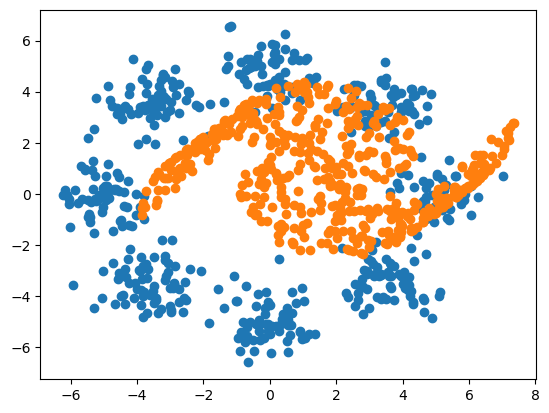

In [17]:
from ott.geometry import pointcloud, geometry

batch_size1 = 500
batch_size2 = 500

g1 = np.ones((batch_size1)) / batch_size1
g2 = np.ones((batch_size2)) / batch_size2

x0 = sample_8gaussians(batch_size1)
x1 = sample_moons(batch_size2)

plt.scatter(x0[:,0], x0[:,1])
plt.scatter(x1[:,0], x1[:,1])
plt.show()

C = torch.from_numpy(distance.cdist(x0, x1)).to(device)
# We recommended normalizing input distance matrices by the max-value for numerical stability and may make this a default.
C = C / C.max()

To run the method, simply call <tt>` FRLC.FRLC_opt `</tt> on the distance matrices used (e.g. $\mathbf{C}$ for the Wasserstein problem, $\mathbf{A}, \mathbf{B}$ for GW or in addition to $\mathbf{C}$ for FGW). You can toggle the type of optimization with the flag <tt>`Wasserstein=True`</tt> or <tt>`Wasserstein=False`</tt> and <tt>`FGW=True`</tt>. Additional flags <tt>`semiRelaxedLeft=True`</tt>, <tt>`semiRelaxedRight=True`</tt>, or <tt>`semiRelaxedRight=True`</tt> can be set to pick between standard relaxed OT problems. If all flags are False (default), then the OT run is balanced.

By default, we assume that the return is in the form $(\mathbf{Q}, \mathbf{R}, \mathbf{T})$ where one has access to the latent coupling $\mathbf{T}$ and the sub-couplings $\mathbf{Q}$ and $\mathbf{R}$ which map from the observed points to the latent points. Setting <tt>` returnFull = True `</tt> will return the full low-rank alignment matrix $\mathbf{P}$ instead.

Iteration: 0


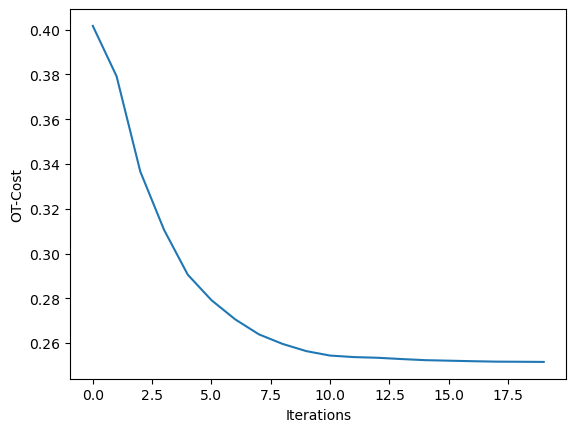

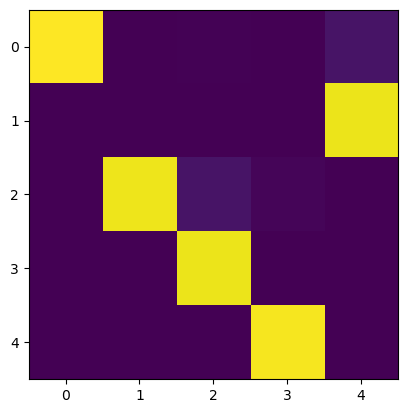

OT cost of FRLC: 0.2515584156057278
tensor([0.0020, 0.0020, 0.0020, 0.0020, 0.0020, 0.0020, 0.0020, 0.0020, 0.0020,
        0.0020, 0.0020, 0.0020, 0.0020, 0.0020, 0.0020, 0.0020, 0.0020, 0.0020,
        0.0020, 0.0020, 0.0020, 0.0020, 0.0020, 0.0020, 0.0020, 0.0020, 0.0020,
        0.0020, 0.0020, 0.0020, 0.0020, 0.0020, 0.0020, 0.0020, 0.0020, 0.0020,
        0.0020, 0.0020, 0.0020, 0.0020, 0.0020, 0.0020, 0.0020, 0.0020, 0.0020,
        0.0020, 0.0020, 0.0020, 0.0020, 0.0020, 0.0020, 0.0020, 0.0020, 0.0020,
        0.0020, 0.0020, 0.0020, 0.0020, 0.0020, 0.0020, 0.0020, 0.0020, 0.0020,
        0.0020, 0.0020, 0.0020, 0.0020, 0.0020, 0.0020, 0.0020, 0.0020, 0.0020,
        0.0020, 0.0020, 0.0020, 0.0020, 0.0020, 0.0020, 0.0020, 0.0020, 0.0020,
        0.0020, 0.0020, 0.0020, 0.0020, 0.0020, 0.0020, 0.0020, 0.0020, 0.0020,
        0.0020, 0.0020, 0.0020, 0.0020, 0.0020, 0.0020, 0.0020, 0.0020, 0.0020,
        0.0020, 0.0020, 0.0020, 0.0020, 0.0020, 0.0020, 0.0020, 0.0020, 0.0020,
    

In [41]:
P, errs = FRLC.FRLC_opt(C, device=device, r=5, max_iter=20, returnFull=True, gamma=70, max_inneriters_balanced=500, max_inneriters_relaxed=500)

print(f'OT cost of FRLC: {errs[-1].item()}')

print(P.sum(axis=0))
print(P.sum(axis=1))
print(P.sum())
print(np.linalg.svd(P)[1])

In [ ]:
import torch
import cvxpy as cp
import numpy as np
import gurobipy as gp
import time
import os

def simplex_projection(s):
    """Projection onto the unit simplex."""
    if np.sum(s) <=1 and np.alltrue(s >= 0):
        return s
    u = np.sort(s)[::-1]
    cssv = np.cumsum(u)
    rho = np.nonzero(u * np.arange(1, len(u)+1) > (cssv - 1))[0][-1]
    theta = (cssv[rho] - 1) / (rho + 1.0)
    return np.maximum(s-theta, 0)

def nuclear_projection(A):
    """Projection onto nuclear norm ball."""
    U, s, V = np.linalg.svd(A, full_matrices=False)
    s = simplex_projection(s)
    return U.dot(np.diag(s).dot(V))

def solve_nuclear_ot(C: np.ndarray, g1: np.ndarray, g2: np.ndarray, k: int, gamma: float, max_iter: int = 100, tolerance: float = 1e-4, rho: float = 1000):
    P2 = np.zeros_like(C)
    D  = np.zeros_like(C)

    iteration = 0
    while iteration < max_iter:
        start_time_euc_ot = time.time()
        P1, objective = solve_euclidean_reg_ot_cvxpy(C, g1, g2, P2 - D, rho=rho) # can replace with Sinkhorn type solver
        end_time_euc_ot = time.time()

        start_time_nuc_proj = time.time()
        P2 = (gamma * k) * nuclear_projection((P1 + D) / (gamma * k))
        end_time_nuc_proj = time.time()

        R  = P1 - P2
        D  = D + R

        print(f"Iteration {iteration}")
        print(f"Objective: {np.sum(C * P1)}")
        print(f"Residual Norm: {np.linalg.norm(R)}")
        print(f"Time for Euclidean OT: {end_time_euc_ot - start_time_euc_ot}")
        print(f"Time for Nuclear Projection: {end_time_nuc_proj - start_time_nuc_proj}")

        iteration += 1
        if np.linalg.norm(R, "fro") < tolerance and iteration > 1:
            break

    return P1, np.sum(C * P1)
    
def solve_euclidean_reg_ot_cvxpy(
    C: np.ndarray, 
    g1: np.ndarray, 
    g2: np.ndarray, 
    P_reg: np.ndarray, 
    rho: float = 0.1,
    solver: str = "MOSEK"
):
    m, n = C.shape
    if g1.shape != (m,) or g2.shape != (n,):
        raise ValueError("Dimension mismatch between C, g1, and g2.")

    P = cp.Variable((m, n), nonneg=True)

    ones_n = np.ones(n)
    ones_m = np.ones(m)

    constraints = [
        P @ ones_n == g1,
        P.T @ ones_m == g2
    ]

    objective = cp.Minimize(cp.sum(cp.multiply(C, P)) + rho * cp.norm(P - P_reg, "fro")**2)
    prob = cp.Problem(objective, constraints)
    prob.solve(solver=solver, verbose=False)

    if prob.status not in ("optimal", "optimal_inaccurate"):
        raise RuntimeError(f"Solver did not converge: status = {prob.status}")

    return P.value, prob.value

def solve_nuclear_ot_cvxpy(C: np.ndarray, g1: np.ndarray, g2: np.ndarray, k: int,
                     gamma: float, solver: str = "MOSEK"):
    m, n = C.shape
    if g1.shape != (m,) or g2.shape != (n,):
        raise ValueError("Dimension mismatch between C, g1, and g2.")

    P = cp.Variable((m, n), nonneg=True)

    ones_n = np.ones(n)
    ones_m = np.ones(m)

    constraints = [
        P @ ones_n == g1,
        P.T @ ones_m == g2,
        cp.norm(P, "nuc") <= gamma * k,
    ]

    objective = cp.Minimize(cp.sum(cp.multiply(C, P)))
    prob = cp.Problem(objective, constraints)
    prob.solve(solver=solver, verbose=True)

    if prob.status not in ("optimal", "optimal_inaccurate"):
        raise RuntimeError(f"Solver did not converge: status = {prob.status}")

    return P.value, prob.value
    
P, obj = solve_nuclear_ot(
    C.cpu().numpy(),
    g1,
    g2,
    5,
    1.0 / (min(g1.shape[0], g2.shape[0])), # gamma \defeq max {||P||_\sigma : P \in \Pi_{a,b}}
    max_iter=100,
    tolerance=1e-4,
    rho=500,
)

                                     CVXPY                                     
                                     v1.6.0                                    
(CVXPY) May 08 11:41:50 AM: Your problem has 250000 variables, 1001 constraints, and 0 parameters.
(CVXPY) May 08 11:41:50 AM: It is compliant with the following grammars: DCP, DQCP
(CVXPY) May 08 11:41:50 AM: (If you need to solve this problem multiple times, but with different data, consider using parameters.)
(CVXPY) May 08 11:41:50 AM: CVXPY will first compile your problem; then, it will invoke a numerical solver to obtain a solution.
(CVXPY) May 08 11:41:50 AM: Your problem is compiled with the CPP canonicalization backend.
-------------------------------------------------------------------------------
                                  Compilation                                  
-------------------------------------------------------------------------------
(CVXPY) May 08 11:41:50 AM: Compiling problem (target solver=MOSE

/opt/homebrew/Caskroom/miniconda/base/lib/python3.12/site-packages/mosek/__init__.py:18617: UserWarning: Argument sub in putvarboundlist: Incorrect array format causing data to be copied
  warnings.warn("Argument sub in putvarboundlist: Incorrect array format causing data to be copied");
/opt/homebrew/Caskroom/miniconda/base/lib/python3.12/site-packages/mosek/__init__.py:18925: UserWarning: Argument subj in putclist: Incorrect array format causing data to be copied
  warnings.warn("Argument subj in putclist: Incorrect array format causing data to be copied");
/opt/homebrew/Caskroom/miniconda/base/lib/python3.12/site-packages/mosek/__init__.py:18349: UserWarning: Argument sub in putconboundlist: Incorrect array format causing data to be copied
  warnings.warn("Argument sub in putconboundlist: Incorrect array format causing data to be copied");


(CVXPY) May 08 11:42:46 AM: Problem
(CVXPY) May 08 11:42:46 AM:   Name                   :                 
(CVXPY) May 08 11:42:46 AM:   Objective sense        : maximize        
(CVXPY) May 08 11:42:46 AM:   Type                   : CONIC (conic optimization problem)
(CVXPY) May 08 11:42:46 AM:   Constraints            : 500500          
(CVXPY) May 08 11:42:46 AM:   Affine conic cons.     : 0               
(CVXPY) May 08 11:42:46 AM:   Disjunctive cons.      : 0               
(CVXPY) May 08 11:42:46 AM:   Cones                  : 0               
(CVXPY) May 08 11:42:46 AM:   Scalar variables       : 251001          
(CVXPY) May 08 11:42:46 AM:   Matrix variables       : 1 (scalarized: 500500)
(CVXPY) May 08 11:42:46 AM:   Integer variables      : 0               
(CVXPY) May 08 11:42:46 AM: 
(CVXPY) May 08 11:42:46 AM: Optimizer started.
(CVXPY) May 08 11:42:46 AM: Presolve started.
(CVXPY) May 08 11:42:46 AM: Linear dependency checker started.
(CVXPY) May 08 11:42:46 AM: Linear 

: 

In [45]:
from sklearn.decomposition import NMF

def sinkhorn_rescaling(L, R, g1, g2, max_iter=1000, tol=1e-12):
    rescaling_rows = True
    for _ in range(max_iter):
        if rescaling_rows:
            row_sum = L @ R @ np.ones(R.shape[1])
            rescaling_matrix = np.diag(g1 / row_sum)
            L = rescaling_matrix @ L
            rescaling_rows = False
        else:
            col_sum = R.T @ L.T @ np.ones(L.shape[0])
            rescaling_matrix = np.diag(g2 / col_sum)
            R = R @ rescaling_matrix
            rescaling_rows = True
        # Check convergence
        norm1 = np.linalg.norm(L @ R @ np.ones(R.shape[1]) - g1)
        norm2 = np.linalg.norm(R.T @ L.T @ np.ones(L.shape[0]) - g2)
        if norm1 < tol and norm2 < tol:
            break
    return L, R

model = NMF(n_components=5, init='random', random_state=0)
W = model.fit_transform(P)
H = model.components_

L_round, R_round = sinkhorn_rescaling(W, H, g1, g2)
P_round = L_round @ R_round

print("Convex Relaxation Lower Bound:", obj)
print("Convex Relaxation Upper Bound:", (C.cpu().numpy() * P_round).sum())
print("||P1 - g1||_1:", np.sum(np.abs(P_round.sum(axis=0) - g1)))
print("||1^TP - g2||_1:", np.sum(np.abs(P_round.sum(axis=1) - g2)))

Convex Relaxation Lower Bound: 0.2329314275408597
Convex Relaxation Upper Bound: 0.25152739082955544
||P1 - g1||_1: 1.6202317265623378e-15
||1^TP - g2||_1: 1.28493974956706e-08


In [46]:
print("Rank of P_round:", np.linalg.matrix_rank(P_round))

Rank of P_round: 5


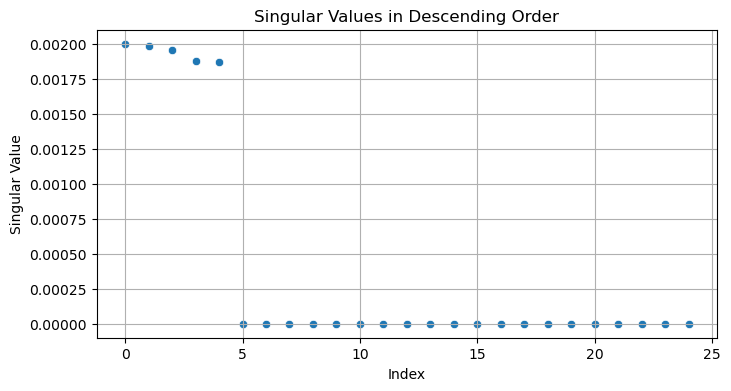

In [47]:
import seaborn as sns

num_vals = 25
sing_vals = np.linalg.svd(P)[1]
plt.figure(figsize=(8, 4))
sns.scatterplot(x=np.arange(num_vals), y=sing_vals[:num_vals])
plt.title("Singular Values in Descending Order")
plt.xlabel("Index")
#plt.yscale("log")
plt.ylabel("Singular Value")
plt.grid(True)
plt.show()